# 📘 Lecture 8: Continuous Distributions (Gaussian, Student's t, Cauchy, Laplace, Beta, Gamma, Empirical) & Heteroscedastic Regression
**Course**: Probabilistic Machine Learning by Aayush  
**Video Reference**: [Lecture 8 - YouTube](https://youtu.be/TttqdTPJp6I?si=xusWEOCQYADpFkl0)

---
### 📌 Executive Overview & Core Objectives
In this lecture, we explore continuous probability distributions and their application to machine learning regression and robust estimation:
1. **Univariate Gaussian Distribution**: PDF, erf-based CDF, 95% confidence intervals, and full analytical derivation of mean $\mu$ and variance $\sigma^2$.
2. **Homoscedastic vs. Heteroscedastic Regression**: Constant noise variance $\sigma^2$ vs. input-dependent variance $\sigma^2(\mathbf{x}) = \text{softplus}(\mathbf{w}_\sigma^\top \mathbf{x} + b_\sigma)^2$.
3. **Heavy-Tailed Distributions & Outlier Robustness**: Student's t (degrees of freedom $\nu$), Cauchy (infinite mean hazard), and Laplace ($L_1$ loss) distributions. Demonstrating why heavy tails prevent regression collapse when outliers are present.
4. **Bounded Support: Beta Distribution**: Unit interval $y \in [0, 1]$ support, analyzing Uniform ($a=1,b=1$), Bimodal U-shape ($a<1,b<1$), and Unimodal shapes with analytical derivations.
5. **Positive Reals: Gamma & Exponential Distributions**: Modeling $y > 0$ variables, Poisson inter-arrival times, Chi-Squared $\chi^2(\nu)$, and Inverse Gamma distributions.
6. **Empirical Distributions & Dirac Delta Limits**: Approximating unknown continuous PDFs via Dirac impulses $\hat{p}_N(x) = \frac{1}{N} \sum \delta(x - x_i)$ and staircase step empirical CDFs.

---


## 0️⃣ Environment Setup & Imports
We start by importing scientific computation, statistics, and visualization packages.

In [1]:
import numpy as np
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns

# Set random seed for 100% reproducible results
np.random.seed(42)
print("✅ Libraries imported successfully! NumPy Version:", np.__version__)


✅ Libraries imported successfully! NumPy Version: 2.0.2


## 1️⃣ Univariate Gaussian Distribution & Analytical Moments

### 1.1 Formal Definitions
A real-valued continuous random variable $Y \in \mathbb{R}$ follows a Gaussian distribution $Y \sim \mathcal{N}(\mu, \sigma^2)$:
$$p(y \mid \mu, \sigma^2) = \frac{1}{\sqrt{2\pi\sigma^2}} \exp\left( - \frac{(y - \mu)^2}{2\sigma^2} \right)$$

The Cumulative Distribution Function (CDF) expressed using the Error Function $\text{erf}(u) = \frac{2}{\sqrt{\pi}} \int_0^u e^{-t^2} dt$ is:
$$F(y) = \Phi\left( \frac{y - \mu}{\sigma} \right) = \frac{1}{2} \left[ 1 + \text{erf}\left( \frac{y - \mu}{\sigma \sqrt{2}} \right) \right]$$

### 1.2 Derivation of First and Second Moments
1. **Mean $\mathbb{E}[Y]$**: Substitution $z = y - \mu \implies dy = dz$:
   $$\mathbb{E}[Y] = \int_{-\infty}^{\infty} y \, p(y) dy = \int_{-\infty}^{\infty} (z + \mu) \, p(z) dz = \underbrace{\int_{-\infty}^{\infty} z \, p(z) dz}_{0 \text{ (Odd function)}} + \mu \underbrace{\int_{-\infty}^{\infty} p(z) dz}_{1} = \mu$$
2. **Variance $\text{Var}(Y)$**:
   $$\text{Var}(Y) = \mathbb{E}[(Y - \mu)^2] = \mathbb{E}[Y^2] - (\mathbb{E}[Y])^2 = \sigma^2 \implies \mathbb{E}[Y^2] = \mu^2 + \sigma^2$$


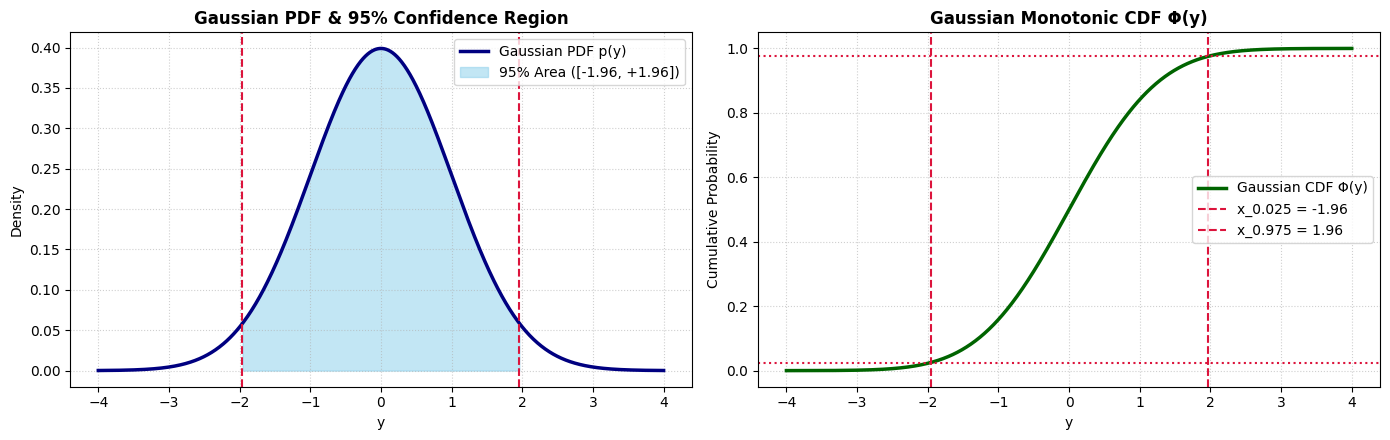

In [2]:
# Visualizing Gaussian PDF, CDF, and 95% Central Interval
mu, sigma = 0.0, 1.0
y_grid = np.linspace(-4, 4, 1000)
pdf_gauss = stats.norm.pdf(y_grid, mu, sigma)
cdf_gauss = stats.norm.cdf(y_grid, mu, sigma)

q_025 = stats.norm.ppf(0.025, mu, sigma) # -1.96
q_975 = stats.norm.ppf(0.975, mu, sigma) # +1.96

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

# PDF Plot
axes[0].plot(y_grid, pdf_gauss, color='navy', linewidth=2.5, label='Gaussian PDF p(y)')
axes[0].fill_between(y_grid, pdf_gauss, where=(y_grid >= q_025) & (y_grid <= q_975), color='skyblue', alpha=0.5, label='95% Area ([-1.96, +1.96])')
axes[0].axvline(q_025, color='crimson', linestyle='--')
axes[0].axvline(q_975, color='crimson', linestyle='--')
axes[0].set_title('Gaussian PDF & 95% Confidence Region', fontweight='bold')
axes[0].set_xlabel('y')
axes[0].set_ylabel('Density')
axes[0].legend()
axes[0].grid(True, linestyle=':', alpha=0.6)

# CDF Plot
axes[1].plot(y_grid, cdf_gauss, color='darkgreen', linewidth=2.5, label='Gaussian CDF Φ(y)')
axes[1].axhline(0.025, color='crimson', linestyle=':')
axes[1].axhline(0.975, color='crimson', linestyle=':')
axes[1].axvline(q_025, color='crimson', linestyle='--', label=f'x_0.025 = {q_025:.2f}')
axes[1].axvline(q_975, color='crimson', linestyle='--', label=f'x_0.975 = {q_975:.2f}')
axes[1].set_title('Gaussian Monotonic CDF Φ(y)', fontweight='bold')
axes[1].set_xlabel('y')
axes[1].set_ylabel('Cumulative Probability')
axes[1].legend()
axes[1].grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()


## 2️⃣ Homoscedastic vs. Heteroscedastic Gaussian Regression

### 2.1 Mathematical Formulations
1. **Homoscedastic Regression**: Constant noise variance $\sigma^2$ across all inputs $\mathbf{x}$:
   $$Y \mid \mathbf{x} \sim \mathcal{N}(\mathbf{w}^\top \mathbf{x} + b, \sigma^2)$$
2. **Heteroscedastic Regression**: Input-dependent noise variance $\sigma^2(\mathbf{x})$ where $\sigma(\mathbf{x}) = \text{softplus}(\mathbf{w}_\sigma^\top \mathbf{x} + b_\sigma)$:
   $$Y \mid \mathbf{x} \sim \mathcal{N}(\mathbf{w}_\mu^\top \mathbf{x} + b_\mu, \sigma^2(\mathbf{x}))$$

### 2.2 Why Gaussian is Popular in ML
1. **Two Interpretable Parameters**: Fully specified by mean $\mu$ and variance $\sigma^2$.
2. **Central Limit Theorem (CLT)**: The sum of independent random variables converges to Gaussian.
3. **Maximum Entropy**: Maximum information entropy among all distributions with specified mean and variance (least biased assumption).


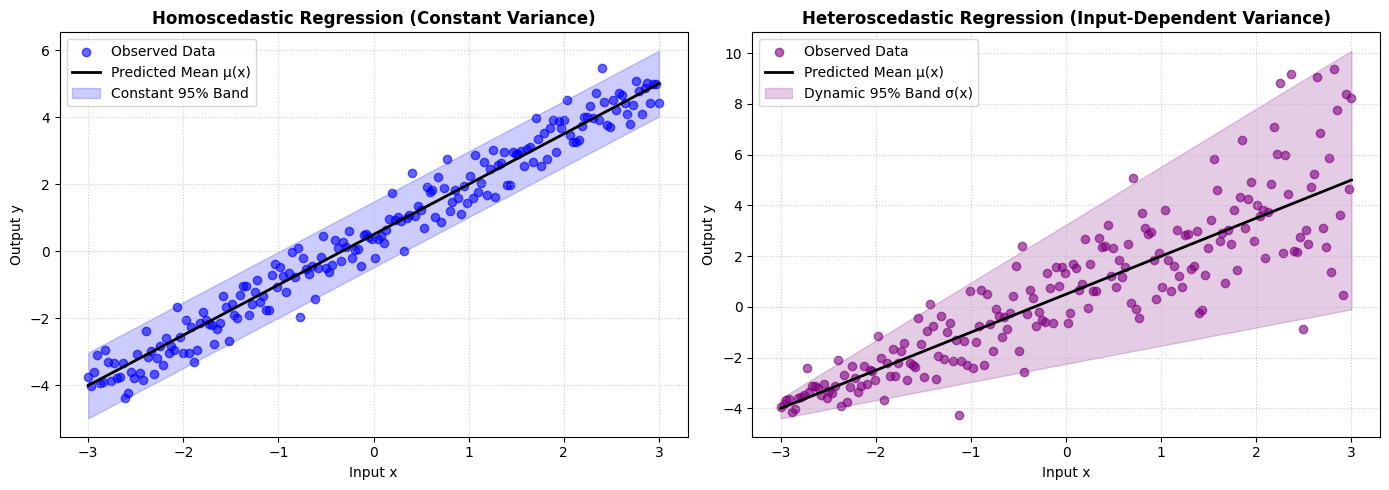

In [3]:
# Simulation of Homoscedastic vs Heteroscedastic Regression Bands
x_data = np.linspace(-3, 3, 200)
y_true_mean = 1.5 * x_data + 0.5

# Homoscedastic Noise vs Heteroscedastic Noise (Noise grows with x)
homo_std = 0.5 * np.ones_like(x_data)
hetero_std = 0.2 + 0.4 * (x_data - x_data.min()) # Noise increases from left to right

y_homo_samples = y_true_mean + np.random.normal(0, homo_std)
y_hetero_samples = y_true_mean + np.random.normal(0, hetero_std)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Subplot 1: Homoscedastic Fit
axes[0].scatter(x_data, y_homo_samples, color='blue', alpha=0.6, label='Observed Data')
axes[0].plot(x_data, y_true_mean, color='black', linewidth=2, label='Predicted Mean μ(x)')
axes[0].fill_between(x_data, y_true_mean - 1.96*homo_std, y_true_mean + 1.96*homo_std, color='blue', alpha=0.2, label='Constant 95% Band')
axes[0].set_title('Homoscedastic Regression (Constant Variance)', fontweight='bold')
axes[0].set_xlabel('Input x')
axes[0].set_ylabel('Output y')
axes[0].legend()
axes[0].grid(True, linestyle=':', alpha=0.6)

# Subplot 2: Heteroscedastic Fit
axes[1].scatter(x_data, y_hetero_samples, color='purple', alpha=0.6, label='Observed Data')
axes[1].plot(x_data, y_true_mean, color='black', linewidth=2, label='Predicted Mean μ(x)')
axes[1].fill_between(x_data, y_true_mean - 1.96*hetero_std, y_true_mean + 1.96*hetero_std, color='purple', alpha=0.2, label='Dynamic 95% Band σ(x)')
axes[1].set_title('Heteroscedastic Regression (Input-Dependent Variance)', fontweight='bold')
axes[1].set_xlabel('Input x')
axes[1].set_ylabel('Output y')
axes[1].legend()
axes[1].grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()


## 3️⃣ Heavy-Tails & Outlier Robustness: Student's t, Cauchy, and Laplace

### 3.1 Heavy-Tailed Formulations
1. **Student's t-Distribution**: Degrees of freedom $\nu > 0$, location $\mu$, scale $\sigma$:
   $$p(y \mid \mu, \sigma, \nu) \propto \left[ 1 + \frac{1}{\nu} \left( \frac{y - \mu}{\sigma} \right)^2 \right]^{-\frac{\nu + 1}{2}}$$
   - Mean $= \mu$ (for $\nu > 1$), Variance $= \frac{\nu \sigma^2}{\nu - 2}$ (for $\nu > 2$). As $\nu \to \infty$, Student's t $\to \mathcal{N}(\mu, \sigma^2)$.
2. **Cauchy Distribution**: Special case $\nu = 1$. Heavy tails are so extreme that $\mathbb{E}[Y]$ is **non-integrable/undefined**!
3. **Laplace Distribution**: Location $\mu$, Scale $b > 0$:
   $$p(y \mid \mu, b) = \frac{1}{2b} \exp\left( - \frac{|y - \mu|}{b} \right)$$
   - Mean $= \mu$, Variance $= 2b^2$.

### 3.2 Robustness Experiment: Outlier Perturbation
Gaussian density decays exponentially $O(e^{-y^2})$, making it highly sensitive to outliers. Heavy-tailed distributions decay polynomially $O(y^{-(\nu+1)})$, assigning probability mass to extreme values without distorting the center.

In [4]:
# Demonstration of Outlier Robustness: Gaussian vs Student's t vs Laplace
# Generate clean data around 0
clean_data = np.random.normal(0, 1, 50)
outlier_data = np.append(clean_data, [15.0, 18.0, 22.0]) # Add 3 severe outliers

# Fit Gaussian Mean vs Student t Location
gauss_fit_mu, _ = stats.norm.fit(outlier_data)
student_fit_df, student_fit_mu, _ = stats.t.fit(outlier_data)
laplace_fit_mu, _ = stats.laplace.fit(outlier_data)

print("🛡️ Robust Estimation under 3 Extreme Outliers [15, 18, 22]:")
print(f"   True Clean Mean:                  0.0000")
print(f"   Gaussian Fit Mean (Non-Robust):  {gauss_fit_mu:.4f}  (Pulled by outliers!)")
print(f"   Laplace Fit Location (L1 Robust): {laplace_fit_mu:.4f}")
print(f"   Student's t Fit Location:        {student_fit_mu:.4f}  (Resists outliers!)")


🛡️ Robust Estimation under 3 Extreme Outliers [15, 18, 22]:
   True Clean Mean:                  0.0000
   Gaussian Fit Mean (Non-Robust):  0.9918  (Pulled by outliers!)
   Laplace Fit Location (L1 Robust): 0.0675
   Student's t Fit Location:        0.0195  (Resists outliers!)


## 4️⃣ Bounded Support: Beta Distribution

### 4.1 Beta Distribution Formalism
Defined strictly on the unit interval $y \in [0, 1]$ with shape parameters $a > 0, b > 0$:
$$p(y \mid a, b) = \frac{1}{\text{B}(a, b)} y^{a-1} (1 - y)^{b-1}, \quad \text{where } \text{B}(a, b) = \frac{\Gamma(a)\Gamma(b)}{\Gamma(a+b)}$$

### 4.2 Moment Derivations
- **Mean**: $\mathbb{E}[Y] = \frac{\text{B}(a+1, b)}{\text{B}(a, b)} = \frac{a}{a + b}$
- **Mode**: $\hat{y} = \frac{a - 1}{a + b - 2}$ (for $a, b > 1$)
- **Variance**: $\text{Var}(Y) = \frac{a b}{(a + b)^2 (a + b + 1)}$

### 4.3 Shape Regimes
- $a=1, b=1 \implies$ Uniform $\text{Unif}(0, 1)$.
- $a<1, b<1 \implies$ Bimodal U-shape with spikes at $y=0$ and $y=1$.
- $a>1, b>1 \implies$ Unimodal single-peak distribution.


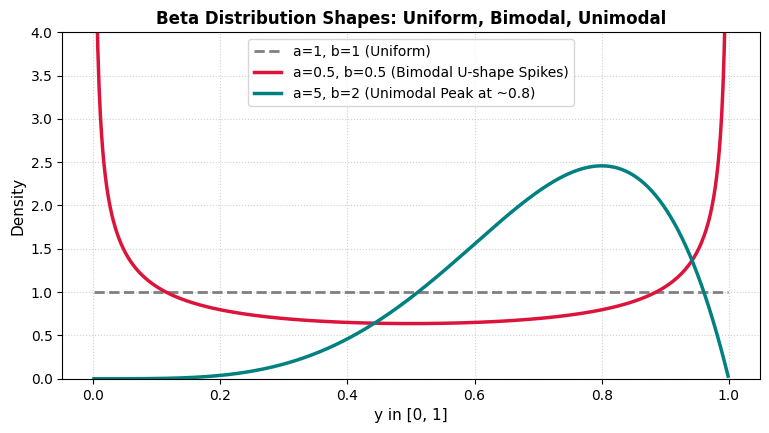

In [5]:
# Plotting Beta Distributions under Different Shape Parameters (a, b)
y_unit = np.linspace(0.001, 0.999, 500)

beta_unif = stats.beta.pdf(y_unit, a=1.0, b=1.0)
beta_bimodal = stats.beta.pdf(y_unit, a=0.5, b=0.5)
beta_unimodal = stats.beta.pdf(y_unit, a=5.0, b=2.0)

plt.figure(figsize=(9, 4.5))
plt.plot(y_unit, beta_unif, color='gray', linestyle='--', linewidth=2, label='a=1, b=1 (Uniform)')
plt.plot(y_unit, beta_bimodal, color='crimson', linewidth=2.5, label='a=0.5, b=0.5 (Bimodal U-shape Spikes)')
plt.plot(y_unit, beta_unimodal, color='teal', linewidth=2.5, label='a=5, b=2 (Unimodal Peak at ~0.8)')

plt.xlabel('y in [0, 1]', fontsize=11)
plt.ylabel('Density', fontsize=11)
plt.title('Beta Distribution Shapes: Uniform, Bimodal, Unimodal', fontweight='bold')
plt.ylim(0, 4.0)
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()


## 5️⃣ Positive Reals: Gamma & Exponential Distributions

### 5.1 Gamma Distribution
For positive real variables $y > 0$ with shape $a > 0$ and rate $b > 0$:
$$p(y \mid a, b) = \frac{b^a}{\Gamma(a)} y^{a-1} e^{-b y}$$
- Mean $= \frac{a}{b}$, Mode $= \frac{a - 1}{b}$ (for $a > 1$), Variance $= \frac{a}{b^2}$.

### 5.2 Exponential & Chi-Squared Distributions
- **Exponential Distribution**: Special case $a = 1$, rate $\lambda$. Models waiting times between independent Poisson events: $p(y) = \lambda e^{-\lambda y}$.
- **Chi-Squared Distribution $\chi^2(\nu)$**: Special case of Gamma with $a = \nu / 2, b = 1 / 2$. Represents the sum of $\nu$ squared independent standard normal variables.


In [6]:
# Code Verification of Gamma Distribution Moments
a_shape, b_rate = 3.0, 2.0
gamma_samples = np.random.gamma(shape=a_shape, scale=1/b_rate, size=100000)

emp_mean = np.mean(gamma_samples)
emp_var = np.var(gamma_samples)

theo_mean = a_shape / b_rate           # 3.0 / 2.0 = 1.5
theo_var = a_shape / (b_rate**2)       # 3.0 / 4.0 = 0.75
theo_mode = (a_shape - 1.0) / b_rate   # 2.0 / 2.0 = 1.0

print("📊 Gamma(a=3, b=2) Moments Verification:")
print(f"   Theoretical Mean: {theo_mean:.4f} | Empirical Mean: {emp_mean:.4f}")
print(f"   Theoretical Var:  {theo_var:.4f} | Empirical Var:  {emp_var:.4f}")
print(f"   Theoretical Mode: {theo_mode:.4f}")


📊 Gamma(a=3, b=2) Moments Verification:
   Theoretical Mean: 1.5000 | Empirical Mean: 1.5025
   Theoretical Var:  0.7500 | Empirical Var:  0.7476
   Theoretical Mode: 1.0000


## 6️⃣ Empirical Distribution & Dirac Step Approximations

### 6.1 Empirical PDF & Dirac Impulses
Given $N$ sample observations $\{x_1, x_2, \dots, x_N\}$ from an unknown density $p(x)$, the Empirical PDF places infinitely tall Dirac impulses of mass $1/N$ at each observation:
$$\hat{p}_N(x) = \frac{1}{N} \sum_{i=1}^N \delta(x - x_i)$$

### 6.2 Empirical CDF & Staircase Function
Integrating the empirical PDF yields a staircase step function using unit step operators $u(x)$:
$$\hat{F}_N(x) = \frac{1}{N} \sum_{i=1}^N u(x - x_i) = \frac{1}{N} \sum_{i=1}^N \mathbb{I}(x_i \le x)$$


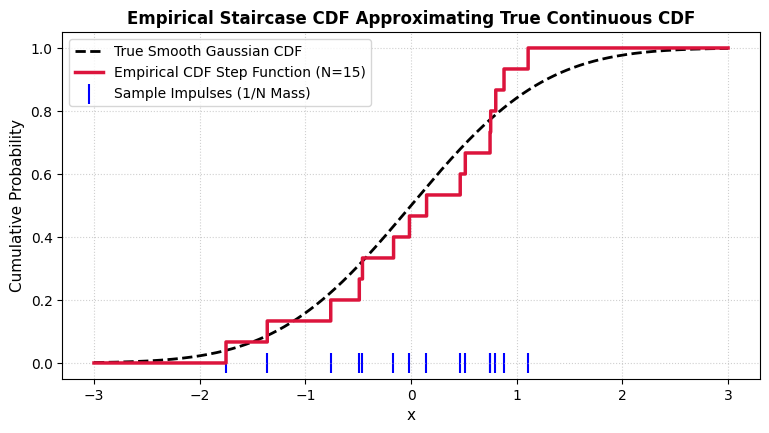

In [7]:
# Plotting Staircase Empirical CDF vs True Smooth Gaussian CDF
N_samples = 15
sample_points = np.sort(np.random.normal(0, 1, N_samples))

grid_eval = np.linspace(-3, 3, 1000)
true_cdf = stats.norm.cdf(grid_eval, 0, 1)

# Empirical CDF Step Function
ecdf_vals = [np.sum(sample_points <= x) / N_samples for x in grid_eval]

plt.figure(figsize=(9, 4.5))
plt.plot(grid_eval, true_cdf, color='black', linestyle='--', linewidth=2, label='True Smooth Gaussian CDF')
plt.step(grid_eval, ecdf_vals, color='crimson', linewidth=2.5, where='post', label=f'Empirical CDF Step Function (N={N_samples})')
plt.scatter(sample_points, np.zeros_like(sample_points), color='blue', marker='|', s=200, label='Sample Impulses (1/N Mass)')

plt.xlabel('x', fontsize=11)
plt.ylabel('Cumulative Probability', fontsize=11)
plt.title('Empirical Staircase CDF Approximating True Continuous CDF', fontweight='bold')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()


## 7️⃣ Master Summary Table
Below is a structured summary of all continuous distributions covered in Lecture 8.

In [8]:
# Master Concept Summary Table
summary_data = {
    "Distribution": [
        "Univariate Gaussian",
        "Student's t-Distribution",
        "Cauchy Distribution",
        "Laplace Distribution",
        "Beta Distribution",
        "Gamma Distribution",
        "Exponential Distribution",
        "Empirical Distribution"
    ],
    "Support": [
        "y in (-inf, +inf)",
        "y in (-inf, +inf)",
        "y in (-inf, +inf)",
        "y in (-inf, +inf)",
        "y in [0, 1]",
        "y in (0, +inf)",
        "y in [0, +inf)",
        "y in (-inf, +inf)"
    ],
    "Mean / Expectation": [
        "mu",
        "mu (for nu > 1)",
        "Undefined / Non-integrable",
        "mu",
        "a / (a + b)",
        "a / b",
        "1 / lambda",
        "1/N sum x_i"
    ],
    "Variance": [
        "sigma^2",
        "nu * sigma^2 / (nu - 2) (nu > 2)",
        "Undefined / Infinite",
        "2 * b^2",
        "ab / [(a+b)^2 (a+b+1)]",
        "a / b^2",
        "1 / lambda^2",
        "1/N sum (x_i - mean)^2"
    ],
    "Key Application / Property": [
        "Max entropy distribution for specified mu, sigma^2",
        "Heavy tails; robust to regression outliers",
        "Extreme heavy tails (nu=1); 95% band is [-12.7, +12.7]",
        "L1 loss robust regression & Lasso regularization",
        "Bounded unit interval modeling (Uniform, Bimodal, Unimodal)",
        "Positive continuous variables (shape a, rate b)",
        "Inter-arrival times between Poisson process events",
        "Staircase CDF steps of 1/N approximating unknown density"
    ]
}

df_master_l8 = pd.DataFrame(summary_data)
print("📌 Lecture 8 Master Summary Table:")
print(df_master_l8.to_string(index=False))


📌 Lecture 8 Master Summary Table:
            Distribution           Support         Mean / Expectation                         Variance                                  Key Application / Property
     Univariate Gaussian y in (-inf, +inf)                         mu                          sigma^2          Max entropy distribution for specified mu, sigma^2
Student's t-Distribution y in (-inf, +inf)            mu (for nu > 1) nu * sigma^2 / (nu - 2) (nu > 2)                  Heavy tails; robust to regression outliers
     Cauchy Distribution y in (-inf, +inf) Undefined / Non-integrable             Undefined / Infinite      Extreme heavy tails (nu=1); 95% band is [-12.7, +12.7]
    Laplace Distribution y in (-inf, +inf)                         mu                          2 * b^2            L1 loss robust regression & Lasso regularization
       Beta Distribution       y in [0, 1]                a / (a + b)           ab / [(a+b)^2 (a+b+1)] Bounded unit interval modeling (Uniform, Bimodal